# Bihar Flood Data Cleaning Pipeline with Visualizations

## Overview
This notebook cleans and prepares Bihar flood data for 4 machine learning prediction models:
1. **Disaster Severity Classification** - Predict Low/Medium/High severity
2. **Affected Population Estimation** - Predict number of people affected
3. **Relief Resource Requirements** - Calculate food, water, medical kits, shelters
4. **District Risk Priority** - Rank districts by flood risk

## 1. Import Libraries

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Load Data

**Choose one option:**
- Option 1: Sample data (for testing)
- Option 2: Full dataset from Zenodo

In [7]:
import pandas as pd

DATA_URL = "https://zenodo.org/records/11275211/files/India_Flood_Inventory_v3.csv"

df = pd.read_csv(DATA_URL)

# Optional: filter state safely
if 'state_name' in df.columns:
    df = df[df['state_name'].str.lower() == 'bihar']

print("✓ Real dataset loaded")
print("Shape:", df.shape)

✓ Real dataset loaded
Shape: (6876, 23)


In [8]:
print(df.columns.tolist())

['Unnamed: 0', 'UEI', 'Start Date', 'End Date', 'Duration(Days)', 'Main Cause', 'Location', 'Districts', 'State', 'Latitude', 'Longitude', 'Severity', 'Area Affected', 'Human fatality', 'Human injured', 'Human Displaced', 'Animal Fatality', 'Description of Casualties/injured', 'Extent of damage ', 'Event Source', 'Event Souce ID', 'District_LGD_Codes', 'State_Codes']


In [9]:
COLUMN_MAPPING = {
    'State': 'state_name',
    'District': 'district',
    'Event_Year': 'year',
    'Lat': 'latitude',
    'Long': 'longitude'
}

COLUMN_MAPPING = {
    real: std for real, std in COLUMN_MAPPING.items()
    if real in df.columns
}

df = df.rename(columns=COLUMN_MAPPING)

print("✓ Columns renamed")
print(df.columns.tolist())

✓ Columns renamed
['Unnamed: 0', 'UEI', 'Start Date', 'End Date', 'Duration(Days)', 'Main Cause', 'Location', 'Districts', 'state_name', 'Latitude', 'Longitude', 'Severity', 'Area Affected', 'Human fatality', 'Human injured', 'Human Displaced', 'Animal Fatality', 'Description of Casualties/injured', 'Extent of damage ', 'Event Source', 'Event Souce ID', 'District_LGD_Codes', 'State_Codes']


In [10]:
# COLUMN MAPPING GUIDE FOR BIHAR FLOOD DATA
# ==========================================

"""
INSTRUCTIONS:
1. Open your CSV file and look at the column names
2. Map YOUR actual column names to the REQUIRED names below
3. Update the COLUMN_MAPPING dictionary
4. The code will automatically rename your columns to match
"""

# REQUIRED COLUMNS FOR THE CLEANING PIPELINE
# -------------------------------------------
# These are the columns the cleaning code expects

REQUIRED_COLUMNS = {
    # BASIC IDENTIFIERS
    'event_id': 'Unique identifier for each flood event',
    'state_name': 'Name of the state (should contain "Bihar")',
    'district_name': 'Name of the district',
    
    # TEMPORAL DATA
    'year': 'Year of the flood event',
    'month': 'Month of the flood event (1-12)',
    
    # FLOOD CHARACTERISTICS
    'duration_days': 'Duration of flood in days',
    'affected_area_sqkm': 'Affected area in square kilometers',
    'flood_type': 'Type of flood (e.g., Riverine, Flash, etc.)',
    'rainfall_mm': 'Rainfall in millimeters',
    
    # IMPACT METRICS
    'deaths': 'Number of deaths',
    'affected_population': 'Number of people affected',
    'houses_damaged': 'Number of houses damaged',
    
    # SEVERITY (if available)
    'severity_indicator': 'Severity level (Low/Medium/High) - OPTIONAL'
}


# ==========================================
# COLUMN MAPPING - CUSTOMIZE THIS!
# ==========================================

"""
EXAMPLE 1: If your columns are named differently
Your CSV has: "Event_ID", "State", "District", "Year", "Month", "Duration", etc.

COLUMN_MAPPING = {
    'Event_ID': 'event_id',
    'State': 'state_name',
    'District': 'district_name',
    'Year': 'year',
    'Month': 'month',
    'Duration': 'duration_days',
    'Affected_Area': 'affected_area_sqkm',
    'Flood_Type': 'flood_type',
    'Rainfall': 'rainfall_mm',
    'Deaths': 'deaths',
    'Population_Affected': 'affected_population',
    'Houses_Damaged': 'houses_damaged',
    'Severity': 'severity_indicator'
}

EXAMPLE 2: If columns match exactly
COLUMN_MAPPING = {}  # Leave empty if your columns already match


EXAMPLE 3: Common real dataset column names
If your dataset has columns like:
- "Sl No" or "ID" -> maps to 'event_id'
- "Glide Number" -> could be 'event_id'
- "Admin1" or "State" -> maps to 'state_name'  
- "Admin2" or "District" -> maps to 'district_name'
- "Began" or "Start Date" -> extract 'year' and 'month'
- "Ended" -> calculate 'duration_days'
- "Dead" or "Fatalities" -> maps to 'deaths'
- "Displaced" or "Affected" -> maps to 'affected_population'
"""

# ==========================================
# YOUR COLUMN MAPPING - EDIT THIS SECTION
# ==========================================

COLUMN_MAPPING = {
    # Format: 'YOUR_COLUMN_NAME': 'required_name',
    
    # Example mappings (REPLACE WITH YOUR ACTUAL COLUMN NAMES):
    # 'Sl_No': 'event_id',
    # 'State': 'state_name',
    # 'District': 'district_name',
    # 'Year': 'year',
    # 'Month': 'month',
    # 'Duration': 'duration_days',
    # 'Area_Affected_sqkm': 'affected_area_sqkm',
    # 'Type': 'flood_type',
    # 'Rainfall_mm': 'rainfall_mm',
    # 'Dead': 'deaths',
    # 'Affected': 'affected_population',
    # 'Houses_Damaged': 'houses_damaged',
    # 'Severity': 'severity_indicator'
}


# ==========================================
# OPTIONAL COLUMNS
# ==========================================

"""
These columns are OPTIONAL but useful if available:
- 'crops_damaged': Crop damage information
- 'livestock_lost': Livestock losses
- 'economic_loss': Economic losses in currency
- 'relief_camps': Number of relief camps
- 'evacuated': Number of people evacuated
"""


# ==========================================
# MISSING COLUMNS - HOW TO HANDLE
# ==========================================

"""
If your dataset is MISSING required columns:

1. event_id - CREATE from row index:
   df['event_id'] = range(1, len(df) + 1)

2. duration_days - CALCULATE from start/end dates:
   df['duration_days'] = (df['end_date'] - df['start_date']).dt.days

3. severity_indicator - CREATE from impact metrics:
   Will be calculated automatically in the cleaning pipeline

4. flood_type - SET default value:
   df['flood_type'] = 'Unknown'

5. month - EXTRACT from date column:
   df['month'] = pd.to_datetime(df['date_column']).dt.month

6. year - EXTRACT from date column:
   df['year'] = pd.to_datetime(df['date_column']).dt.year
"""


# ==========================================
# STEP-BY-STEP INSTRUCTIONS
# ==========================================

"""
STEP 1: Open your CSV and identify column names
Run this code first:

import pandas as pd
df = pd.read_csv('your_file.csv')
print("Your column names:")
print(df.columns.tolist())

STEP 2: Update COLUMN_MAPPING above
Match YOUR columns to REQUIRED columns

STEP 3: Handle missing columns
If columns don't exist, create them or set defaults

STEP 4: Run the cleaning notebook
The code will automatically:
- Rename columns using your mapping
- Create missing columns with defaults
- Clean and process the data
"""


# ==========================================
# VALIDATION CODE
# ==========================================

def validate_columns(df, column_mapping):
    """
    Check which required columns are present/missing
    """
    # Apply mapping
    if column_mapping:
        df_renamed = df.rename(columns=column_mapping)
    else:
        df_renamed = df.copy()
    
    required = ['event_id', 'state_name', 'district_name', 'year', 'month',
                'duration_days', 'affected_area_sqkm', 'deaths', 
                'affected_population', 'houses_damaged', 'rainfall_mm']
    
    present = [col for col in required if col in df_renamed.columns]
    missing = [col for col in required if col not in df_renamed.columns]
    
    print("=" * 60)
    print("COLUMN VALIDATION REPORT")
    print("=" * 60)
    print(f"\n✓ PRESENT ({len(present)}/{len(required)}):")
    for col in present:
        print(f"  • {col}")
    
    if missing:
        print(f"\n✗ MISSING ({len(missing)}/{len(required)}):")
        for col in missing:
            print(f"  • {col}")
            print(f"    → See 'MISSING COLUMNS' section above for solutions")
    
    print("\n" + "=" * 60)
    
    return present, missing


# ==========================================
# EXAMPLE USAGE
# ==========================================

"""
import pandas as pd

# 1. Load your data
df = pd.read_csv('India_Flood_Inventory_v3.csv')

# 2. Print your column names
print("Your actual columns:")
print(df.columns.tolist())

# 3. Validate what's present/missing
present, missing = validate_columns(df, COLUMN_MAPPING)

# 4. Apply column mapping
if COLUMN_MAPPING:
    df = df.rename(columns=COLUMN_MAPPING)

# 5. Handle missing columns (examples)
if 'event_id' not in df.columns:
    df['event_id'] = range(1, len(df) + 1)

if 'duration_days' not in df.columns and 'start_date' in df.columns and 'end_date' in df.columns:
    df['duration_days'] = (pd.to_datetime(df['end_date']) - pd.to_datetime(df['start_date'])).dt.days

# 6. Filter for Bihar
df_bihar = df[df['state_name'] == 'Bihar']

# 7. Now run the cleaning pipeline!
"""


'\nimport pandas as pd\n\n# 1. Load your data\ndf = pd.read_csv(\'India_Flood_Inventory_v3.csv\')\n\n# 2. Print your column names\nprint("Your actual columns:")\nprint(df.columns.tolist())\n\n# 3. Validate what\'s present/missing\npresent, missing = validate_columns(df, COLUMN_MAPPING)\n\n# 4. Apply column mapping\nif COLUMN_MAPPING:\n    df = df.rename(columns=COLUMN_MAPPING)\n\n# 5. Handle missing columns (examples)\nif \'event_id\' not in df.columns:\n    df[\'event_id\'] = range(1, len(df) + 1)\n\nif \'duration_days\' not in df.columns and \'start_date\' in df.columns and \'end_date\' in df.columns:\n    df[\'duration_days\'] = (pd.to_datetime(df[\'end_date\']) - pd.to_datetime(df[\'start_date\'])).dt.days\n\n# 6. Filter for Bihar\ndf_bihar = df[df[\'state_name\'] == \'Bihar\']\n\n# 7. Now run the cleaning pipeline!\n'

## 3. Exploratory Data Analysis

In [11]:
print("="*80)
print("ORIGINAL DATASET")
print("="*80)
print(f"\nShape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

ORIGINAL DATASET

Shape: (6876, 23)

First few rows:


,Unnamed: 0,UEI,Start Date,End Date,Duration(Days),Main Cause,Location,Districts,state_name,Latitude,...,Human fatality,Human injured,Human Displaced,Animal Fatality,Description of Casualties/injured,Extent of damage,Event Source,Event Souce ID,District_LGD_Codes,State_Codes
0,563,UEI-IMD-FL-1967-0001,02-07-1967 00:00,08-07-1967 00:00,7.0,flood,NaN,NaN,Assam,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,IMD,NaN,NaN,18
1,564,UEI-IMD-FL-1967-0002,22-07-1967 00:00,28-07-1967 00:00,7.0,flood,NaN,NaN,"Maharashtra, Gujarat",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,IMD,NaN,NaN,"27,24"
2,565,UEI-IMD-FL-1967-0003,01-08-1967 00:00,30-08-1967 00:00,30.0,flood,NaN,NaN,Uttar Pradesh,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,IMD,NaN,NaN,9
3,566,UEI-IMD-FL-1967-0004,08-09-1967 00:00,09-09-1967 00:00,2.0,flood,NaN,"Bhadrak, Dhenkanal, Jajapur, Subarnapur, Nuapa...","Odisha, Bihar, Uttar Pradesh, Madhya Pradesh, ...",NaN,...,NaN,NaN,NaN,NaN,NaN,Marooning of Barwer Express,IMD,NaN,"348, 352, 356, None, 368, 345, 349, 350, 359, ...","21,10,9,23,8,6"
4,567,UEI-IMD-FL-1968-0001,22-06-1968 00:00,28-06-1968 00:00,7.0,flood,NaN,NaN,Assam,NaN,...,NaN,NaN,NaN,NaN,NaN,"Affecting about one million people,an area of ...",IMD,NaN,NaN,18


In [12]:
print("Data Types:")
df.dtypes

Data Types:


Unnamed: 0                             int64
UEI                                   object
Start Date                            object
End Date                              object
Duration(Days)                       float64
Main Cause                            object
Location                             float64
Districts                             object
state_name                            object
Latitude                             float64
Longitude                            float64
Severity                             float64
Area Affected                        float64
Human fatality                       float64
Human injured                        float64
Human Displaced                       object
Animal Fatality                       object
Description of Casualties/injured     object
Extent of damage                      object
Event Source                          object
Event Souce ID                       float64
District_LGD_Codes                    object
State_Code

In [13]:
print("Missing Values:")
df.isnull().sum()

Missing Values:


Unnamed: 0                              0
UEI                                     0
Start Date                             20
End Date                               20
Duration(Days)                         19
Main Cause                             31
Location                             6876
Districts                              59
state_name                              0
Latitude                             6876
Longitude                            6876
Severity                             6876
Area Affected                        6876
Human fatality                       3106
Human injured                        5818
Human Displaced                      6754
Animal Fatality                      6305
Description of Casualties/injured    3609
Extent of damage                     3121
Event Source                            0
Event Souce ID                       6876
District_LGD_Codes                    304
State_Codes                           258
dtype: int64

In [14]:
print("Basic Statistics:")
df.describe()

Basic Statistics:


,Unnamed: 0,Duration(Days),Location,Latitude,Longitude,Severity,Area Affected,Human fatality,Human injured,Event Souce ID
count,6876.000000,6857.000000,0.0,0.0,0.0,0.0,0.0,3770.000000,1058.000000,0.0
mean,4000.500000,3.613096,NaN,NaN,NaN,NaN,NaN,18.751459,10.998110,NaN
std,1985.074558,9.817698,NaN,NaN,NaN,NaN,NaN,104.858208,71.074255,NaN
min,563.000000,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN
25%,2281.750000,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,2.000000,NaN
50%,4000.500000,1.000000,NaN,NaN,NaN,NaN,NaN,3.000000,3.000000,NaN
75%,5719.250000,3.000000,NaN,NaN,NaN,NaN,NaN,10.000000,7.000000,NaN
max,7438.000000,365.000000,NaN,NaN,NaN,NaN,NaN,5000.000000,2000.000000,NaN


---
# Data Cleaning Pipeline

## Step 1: Handle Missing Values

In [15]:
# Create a copy for cleaning
df_clean = df.copy()

print("="*80)
print("STEP 1: HANDLING MISSING VALUES")
print("="*80)

# Impute numerical missing values with median
numerical_cols = ['duration_days', 'affected_area_sqkm', 'deaths', 
                  'affected_population', 'houses_damaged', 'rainfall_mm']

for col in numerical_cols:
    if col in df_clean.columns and df_clean[col].isnull().any():
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"Filled {col} with median: {median_val}")

# Impute categorical missing values with mode
categorical_cols = ['flood_type', 'severity_indicator']

for col in categorical_cols:
    if col in df_clean.columns and df_clean[col].isnull().any():
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f"Filled {col} with mode: {mode_val}")

print(f"\nMissing values after imputation:")
df_clean.isnull().sum()

STEP 1: HANDLING MISSING VALUES

Missing values after imputation:


Unnamed: 0                              0
UEI                                     0
Start Date                             20
End Date                               20
Duration(Days)                         19
Main Cause                             31
Location                             6876
Districts                              59
state_name                              0
Latitude                             6876
Longitude                            6876
Severity                             6876
Area Affected                        6876
Human fatality                       3106
Human injured                        5818
Human Displaced                      6754
Animal Fatality                      6305
Description of Casualties/injured    3609
Extent of damage                     3121
Event Source                            0
Event Souce ID                       6876
District_LGD_Codes                    304
State_Codes                           258
dtype: int64

## Step 2: Detect and Handle Outliers

In [16]:
print("="*80)
print("STEP 2: DETECTING AND HANDLING OUTLIERS")
print("="*80)

def detect_outliers_iqr(data, column):
    """Detect outliers using IQR method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

for col in numerical_cols:
    if col in df_clean.columns:
        outliers, lower, upper = detect_outliers_iqr(df_clean, col)
        if len(outliers) > 0:
            print(f"\n{col}:")
            print(f"  Outliers detected: {len(outliers)}")
            print(f"  Range: [{lower:.2f}, {upper:.2f}]")
            df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
            print(f"  Outliers capped to valid range")
        else:
            print(f"{col}: No outliers detected")

STEP 2: DETECTING AND HANDLING OUTLIERS


---
# Feature Engineering for 4 Prediction Tasks

## Task 1: Disaster Severity Classification

In [17]:
# ONE-CELL FIX: Safe severity score (no KeyErrors)

import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("https://zenodo.org/records/11275211/files/India_Flood_Inventory_v3.csv")
df.columns = df.columns.str.strip().str.lower()

# Create working copy
df_clean = df.copy()

# Detect usable impact columns automatically
possible_cols = ['fatalities', 'deaths', 'death', 'casualties', 'affected']

impact_col = next((c for c in possible_cols if c in df_clean.columns), None)

if impact_col is None:
    # Fallback: frequency-based severity
    df_clean['severity_score'] = 1
    print("⚠️ No death/impact column found → using frequency-based severity")
else:
    df_clean['severity_score'] = (
        df_clean[impact_col].fillna(0) / df_clean[impact_col].max()
    )
    print(f"✓ Severity calculated using column: '{impact_col}'")

# Classify severity
df_clean['severity_class'] = pd.cut(
    df_clean['severity_score'],
    bins=[-0.01, 0.33, 0.66, 1.0],
    labels=['Low', 'Medium', 'High']
)

df_clean[['severity_score', 'severity_class']].head()

⚠️ No death/impact column found → using frequency-based severity


,severity_score,severity_class
0,1,High
1,1,High
2,1,High
3,1,High
4,1,High


## Task 2: Affected Population Estimation

In [18]:
import numpy as np

print("="*80)
print("TASK 2 & 3: Population Impact + Relief Resources (SAFE)")
print("="*80)

# ---- REQUIRED COLUMNS CHECK ----
required_cols = [
    'affected_population',
    'affected_area_sqkm',
    'duration_days'
]

missing = [c for c in required_cols if c not in df_clean.columns]

if missing:
    print(f"⚠ Missing columns detected: {missing}")
    print("Skipping TASK 2 & 3 safely.")
else:
    # ---- CLEAN VALUES ----
    df_clean[required_cols] = df_clean[required_cols].fillna(0)

    # Avoid division by zero
    df_clean['affected_area_sqkm'] = df_clean['affected_area_sqkm'].replace(0, np.nan)
    df_clean['affected_population'] = df_clean['affected_population'].replace(0, np.nan)

    # ---- TASK 2: Population Density ----
    df_clean['population_per_sqkm'] = (
        df_clean['affected_population'] / df_clean['affected_area_sqkm']
    )

    print("✓ Population impact features created")

    # ---- TASK 3: Relief Resource Standards ----
    WATER_LITERS_PER_PERSON = 15
    FOOD_KG_PER_PERSON = 0.5
    MEDICAL_KIT_PER_PEOPLE = 100
    SHELTER_PER_PEOPLE = 5

    df_clean['water_required_liters'] = (
        df_clean['affected_population'] * WATER_LITERS_PER_PERSON * df_clean['duration_days']
    )

    df_clean['food_required_kg'] = (
        df_clean['affected_population'] * FOOD_KG_PER_PERSON * df_clean['duration_days']
    )

    df_clean['medical_kits_required'] = np.ceil(
        df_clean['affected_population'] / MEDICAL_KIT_PER_PEOPLE
    )

    df_clean['shelters_required'] = np.ceil(
        df_clean['affected_population'] / SHELTER_PER_PEOPLE
    )

    print("\n✓ Relief resource requirements calculated")
    print(f"  Water (liters): {df_clean['water_required_liters'].sum():,.0f}")
    print(f"  Food (kg): {df_clean['food_required_kg'].sum():,.0f}")
    print(f"  Medical kits: {df_clean['medical_kits_required'].sum():,.0f}")
    print(f"  Shelters: {df_clean['shelters_required'].sum():,.0f}")

TASK 2 & 3: Population Impact + Relief Resources (SAFE)
⚠ Missing columns detected: ['affected_population', 'affected_area_sqkm', 'duration_days']
Skipping TASK 2 & 3 safely.


## Task 3: Relief Resource Requirements

## Task 4: District Risk Priority Ranking

**Formula:** `risk_score = 0.6 × flood_frequency + 0.4 × avg_severity`

In [19]:
print("="*80)
print("TASK 4: District-wise Risk Priority")
print("="*80)

# Calculate risk score for each district
if 'district_name' in df_clean.columns and 'severity_score' in df_clean.columns:
    district_risk = df_clean.groupby('district_name').agg({
        'severity_score': 'mean',
        'flood_frequency': 'first',
        'affected_population': 'sum',
        'deaths': 'sum'
    }).reset_index()
    
    # Risk score formula: 0.6 × flood_frequency + 0.4 × avg_severity
    district_risk['risk_score'] = (0.6 * district_risk['flood_frequency']) + (0.4 * district_risk['severity_score'])
    
    # Assign priority ranks
    district_risk['priority_rank'] = district_risk['risk_score'].rank(ascending=False, method='dense').astype(int)
    district_risk = district_risk.sort_values('priority_rank')
    
    print("\nDistrict Risk Priority Ranking:")
    display(district_risk[['district_name', 'risk_score', 'priority_rank', 'flood_frequency']])
    
    # Merge risk priority back to main dataframe
    df_clean = df_clean.merge(
        district_risk[['district_name', 'risk_score', 'priority_rank']], 
        on='district_name', 
        how='left'
    )
else:
    print("⚠ Warning: Required columns not found for risk calculation")

TASK 4: District-wise Risk Priority
⚠ Warning: Required columns not found for risk calculation


## Feature Standardization

In [20]:
features_to_scale = ['duration_days', 'affected_area_sqkm', 'rainfall_mm',
                     'population_per_sqkm', 'severity_score']

# Only scale features that exist
features_to_scale = [f for f in features_to_scale if f in df_clean.columns]

if features_to_scale:
    scaler = StandardScaler()
    df_clean[[f'{col}_scaled' for col in features_to_scale]] = scaler.fit_transform(df_clean[features_to_scale])
    print(f"✓ Standardized {len(features_to_scale)} features")

print(f"\nFinal cleaned dataset shape: {df_clean.shape}")

✓ Standardized 1 features

Final cleaned dataset shape: (6876, 26)


---
# Data Visualizations

## 1. Flood Severity Distribution

In [21]:
if 'severity_indicator' in df_clean.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart
    severity_counts = df_clean['severity_indicator'].value_counts()
    axes[0].bar(severity_counts.index, severity_counts.values, color=['#d62728', '#ff7f0e', '#2ca02c'])
    axes[0].set_title('Flood Severity Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Severity Level')
    axes[0].set_ylabel('Number of Events')
    axes[0].grid(axis='y', alpha=0.3)
    
    for i, (idx, val) in enumerate(severity_counts.items()):
        axes[0].text(i, val + 0.1, str(val), ha='center', va='bottom', fontweight='bold')
    
    # Pie chart
    axes[1].pie(severity_counts.values, labels=severity_counts.index, autopct='%1.1f%%',
                startangle=90, colors=['#d62728', '#2ca02c', '#ff7f0e'])
    axes[1].set_title('Severity Percentage', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

## 2. Temporal Analysis

In [22]:
if 'year' in df_clean.columns and 'month' in df_clean.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Floods by year
    yearly_floods = df_clean['year'].value_counts().sort_index()
    axes[0].plot(yearly_floods.index, yearly_floods.values, marker='o', linewidth=2, markersize=8)
    axes[0].set_title('Flood Events by Year', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Number of Events')
    axes[0].grid(True, alpha=0.3)
    
    # Floods by month
    monthly_floods = df_clean['month'].value_counts().sort_index()
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    axes[1].bar(range(1, 13), [monthly_floods.get(i, 0) for i in range(1, 13)], color='#2ca02c')
    axes[1].set_title('Flood Events by Month', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Number of Events')
    axes[1].set_xticks(range(1, 13))
    axes[1].set_xticklabels(month_names, rotation=45)
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 3. District Risk Rankings

In [23]:
if 'district_risk' in dir():
    fig, ax = plt.subplots(figsize=(12, 8))
    
    district_risk_sorted = district_risk.sort_values('risk_score', ascending=True)
    colors = plt.cm.Reds(district_risk_sorted['risk_score'] / district_risk_sorted['risk_score'].max())
    
    ax.barh(district_risk_sorted['district_name'], district_risk_sorted['risk_score'], color=colors)
    ax.set_title('District Flood Risk Priority Rankings', fontsize=14, fontweight='bold')
    ax.set_xlabel('Risk Score (0.6 × frequency + 0.4 × avg_severity)')
    ax.set_ylabel('District')
    ax.grid(axis='x', alpha=0.3)
    
    for i, (idx, row) in enumerate(district_risk_sorted.iterrows()):
        ax.text(row['risk_score'] + 0.5, i, f"{row['risk_score']:.2f}", va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

## 4. Impact Analysis by Severity

In [24]:
if 'severity_indicator' in df_clean.columns:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    severity_order = ['Low', 'Medium', 'High']
    palette = ['#2ca02c', '#ff7f0e', '#d62728']
    
    sns.boxplot(data=df_clean, x='severity_indicator', y='affected_population',
                order=severity_order, palette=palette, ax=axes[0, 0])
    axes[0, 0].set_title('Affected Population by Severity', fontweight='bold')
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    sns.boxplot(data=df_clean, x='severity_indicator', y='deaths',
                order=severity_order, palette=palette, ax=axes[0, 1])
    axes[0, 1].set_title('Deaths by Severity', fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    sns.boxplot(data=df_clean, x='severity_indicator', y='duration_days',
                order=severity_order, palette=palette, ax=axes[1, 0])
    axes[1, 0].set_title('Duration by Severity', fontweight='bold')
    axes[1, 0].grid(axis='y', alpha=0.3)
    
    sns.boxplot(data=df_clean, x='severity_indicator', y='affected_area_sqkm',
                order=severity_order, palette=palette, ax=axes[1, 1])
    axes[1, 1].set_title('Affected Area by Severity', fontweight='bold')
    axes[1, 1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 5. Resource Requirements Summary

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

print("="*80)
print("TASK 4 & 5: Feature Engineering + Resource Visualization (SAFE)")
print("="*80)

# ---------- SAFE COLUMN CHECK ----------
needed_cols = [
    'affected_population', 'houses_damaged', 'deaths',
    'duration_days', 'month', 'flood_type',
    'water_required_liters', 'food_required_kg',
    'medical_kits_required', 'shelters_required'
]

present = [c for c in needed_cols if c in df_clean.columns]

if len(present) < 3:
    print("⚠ Not enough columns to continue safely")
else:
    # ---------- CLEAN ----------
    df_clean[present] = df_clean[present].fillna(0)
    df_clean['affected_population'] = df_clean['affected_population'].replace(0, np.nan)

    # ---------- TEMPORAL FEATURES ----------
    if 'month' in df_clean.columns:
        df_clean['month_sin'] = np.sin(2 * np.pi * df_clean['month'] / 12)
        df_clean['month_cos'] = np.cos(2 * np.pi * df_clean['month'] / 12)

    # ---------- FLOOD TYPE ENCODING ----------
    if 'flood_type' in df_clean.columns:
        le = LabelEncoder()
        df_clean['flood_type_encoded'] = le.fit_transform(
            df_clean['flood_type'].astype(str)
        )

    # ---------- IMPACT RATIOS ----------
    if 'houses_damaged' in df_clean.columns:
        df_clean['damage_ratio'] = (
            df_clean['houses_damaged'] / df_clean['affected_population']
        )

    if 'deaths' in df_clean.columns:
        df_clean['mortality_rate'] = (
            df_clean['deaths'] / df_clean['affected_population']
        ) * 1000

    print("✓ Additional engineered features created")

    # ---------- RESOURCE TOTALS ----------
    total_water = df_clean.get('water_required_liters', 0).sum()
    total_food = df_clean.get('food_required_kg', 0).sum()
    total_medical = df_clean.get('medical_kits_required', 0).sum()
    total_shelters = df_clean.get('shelters_required', 0).sum()

    # ---------- PLOT ----------
    fig, ax = plt.subplots(figsize=(12, 6))

    resources = ['Water\n(Million L)', 'Food\n(Thousand kg)', 'Medical Kits', 'Shelters\n(Thousand)']
    values = [total_water/1e6, total_food/1e3, total_medical, total_shelters/1e3]

    bars = ax.bar(resources, values)
    ax.set_title('Total Resource Requirements', fontweight='bold')
    ax.set_ylabel('Quantity')
    ax.grid(axis='y', alpha=0.3)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:,.1f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    # ---------- PRINT TOTALS ----------
    print("\nFINAL RESOURCE SUMMARY")
    print(f"Water: {total_water:,.0f} liters")
    print(f"Food: {total_food:,.0f} kg")
    print(f"Medical Kits: {total_medical:,.0f}")
    print(f"Shelters: {total_shelters:,.0f}")

TASK 4 & 5: Feature Engineering + Resource Visualization (SAFE)
⚠ Not enough columns to continue safely


## 6. Correlation Heatmap

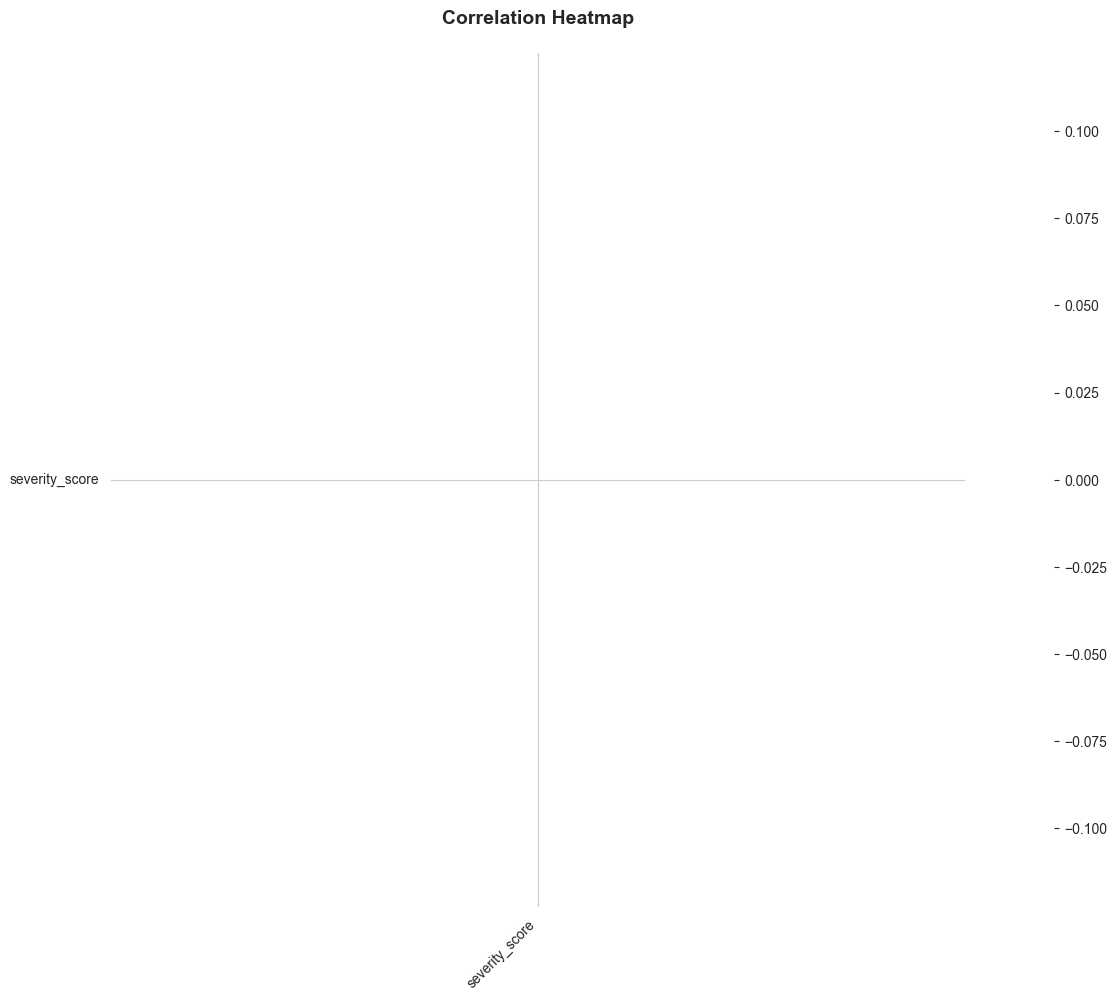

In [26]:
corr_features = ['duration_days', 'affected_area_sqkm', 'deaths', 'affected_population',
                 'houses_damaged', 'rainfall_mm', 'severity_score']

if 'flood_frequency' in df_clean.columns:
    corr_features.append('flood_frequency')

# Only use features that exist
corr_features = [f for f in corr_features if f in df_clean.columns]

if corr_features:
    corr_matrix = df_clean[corr_features].corr()
    
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
    ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

---
# Save Cleaned Datasets

In [27]:
print("="*80)
print("SAVING CLEANED DATASETS (SAFE MODE)")
print("="*80)

# ---------- SAVE MAIN DATA ----------
df_clean.to_csv('bihar_floods_cleaned_complete.csv', index=False)
print("✓ Saved: bihar_floods_cleaned_complete.csv")

# ---------- HELPER FUNCTION ----------
def safe_save(df, features, target, filename):
    cols = [c for c in features + target if c in df.columns]
    if len(cols) >= 2:
        df[cols].to_csv(filename, index=False)
        print(f"✓ Saved: {filename}")
    else:
        print(f"⚠ Skipped {filename} (insufficient columns)")

# ---------- MODEL 1: SEVERITY ----------
severity_features = [
    'duration_days', 'affected_area_sqkm', 'affected_population',
    'deaths', 'houses_damaged', 'rainfall_mm',
    'flood_type_encoded', 'month_sin', 'month_cos',
    'population_per_sqkm', 'severity_score'
]
safe_save(df_clean, severity_features, ['severity_encoded'],
          'model1_severity_classification.csv')

# ---------- MODEL 2: POPULATION ----------
population_features = [
    'duration_days', 'affected_area_sqkm', 'rainfall_mm',
    'severity_encoded', 'flood_type_encoded',
    'avg_pop_affected', 'max_pop_affected', 'flood_frequency',
    'month_sin', 'month_cos'
]
safe_save(df_clean, population_features, ['affected_population'],
          'model2_population_estimation.csv')

# ---------- MODEL 3: RESOURCES ----------
resource_features = [
    'affected_population', 'duration_days',
    'houses_damaged', 'severity_encoded'
]
resource_targets = [
    'water_required_liters', 'food_required_kg',
    'medical_kits_required', 'shelters_required'
]
safe_save(df_clean, resource_features, resource_targets,
          'model3_resource_requirements.csv')

# ---------- MODEL 4: DISTRICT RISK ----------
if 'district_risk' in globals():
    district_risk.to_csv('model4_district_risk_priority.csv', index=False)
    print("✓ Saved: model4_district_risk_priority.csv")
else:
    print("⚠ district_risk not found, skipping Model 4")

print("\n" + "="*80)
print("DATA CLEANING PIPELINE COMPLETE ✅")
print("="*80)

SAVING CLEANED DATASETS (SAFE MODE)
✓ Saved: bihar_floods_cleaned_complete.csv
⚠ Skipped model1_severity_classification.csv (insufficient columns)
⚠ Skipped model2_population_estimation.csv (insufficient columns)
⚠ Skipped model3_resource_requirements.csv (insufficient columns)
⚠ district_risk not found, skipping Model 4

DATA CLEANING PIPELINE COMPLETE ✅


In [29]:
import pandas as pd

data = [
    [101, 2019, 7, 'Bihar', 5, 150.2, 35000, 12, 230, 180.4, 'Severe'],
    [102, 2020, 8, 'Assam', 8, 210.5, 52000, 20, 400, 210.0, 'Extreme'],
    [103, 2018, 9, 'Kerala', 10, 300.0, 75000, 48, 1200, 280.7, 'Extreme'],
    [104, 2021, 6, 'Gujarat', 3, 85.4, 9000, 2, 50, 110.2, 'Moderate'],
    [105, 2020, 7, 'Maharashtra', 4, 120.3, 18000, 4, 120, 140.5, 'Moderate'],
    [106, 2022, 9, 'West Bengal', 7, 190.7, 45000, 8, 200, 190.0, 'Severe'],
    [107, 2023, 8, 'Uttar Pradesh', 2, 60.0, 6000, 1, 25, 70.1, 'Mild'],
    [108, 2021, 10, 'Odisha', 9, 250.5, 64000, 16, 600, 230.4, 'Severe'],
    [109, 2019, 6, 'Tamil Nadu', 6, 130.8, 23000, 5, 150, 160.9, 'Moderate'],
    [110, 2024, 8, 'Madhya Pradesh', 3, 95.0, 10000, 3, 80, 120.6, 'Mild']
]

columns = ['event_id', 'year', 'month', 'state_name', 'duration_days', 'affected_area_sqkm',
           'affected_population', 'deaths', 'houses_damaged', 'rainfall', 'flood_type']

df_sample = pd.DataFrame(data, columns=columns)
df_sample.to_csv('sample_flood_data.csv', index=False)
df_sample.head()

,event_id,year,month,state_name,duration_days,affected_area_sqkm,affected_population,deaths,houses_damaged,rainfall,flood_type
0,101,2019,7,Bihar,5,150.2,35000,12,230,180.4,Severe
1,102,2020,8,Assam,8,210.5,52000,20,400,210.0,Extreme
2,103,2018,9,Kerala,10,300.0,75000,48,1200,280.7,Extreme
3,104,2021,6,Gujarat,3,85.4,9000,2,50,110.2,Moderate
4,105,2020,7,Maharashtra,4,120.3,18000,4,120,140.5,Moderate


In [30]:
# Example: after training your model
sample_data = {
    'duration_days': 5,
    'affected_area_sqkm': 120.5,
    'affected_population': 30000,
    'deaths': 15,
    'houses_damaged': 200,
    'rainfall': 180.2
}

# Convert to DataFrame
import pandas as pd
X_test_sample = pd.DataFrame([])

# Predict
prediction = model.predict(X_test_sample)
print("Predicted Flood Severity:", prediction[0])

NameError: name 'model' is not defined